In [1]:
from baja.sample_data import load_cubs_traj_data
import numpy as np
import matplotlib.pyplot as plt
import rerun as rr


In [ ]:
df = load_cubs_traj_data("0.1s")[:200] 
# df = pd.read_parquet("../data/cub_sample_traj.parquet")
seq_len = len(df)

In [3]:
ts = df.index.to_numpy().astype(np.datetime64)
target_pos = df[["x", "y", "z"]].to_numpy()
rng = np.random.default_rng(12345)
n_points = 50
offsets = rng.normal(scale=0.5, size=(n_points, seq_len, 3))
radii = rng.uniform(0.1, 0.3, size=[seq_len, n_points])
cloud = target_pos + offsets
B, T, D = cloud.shape

sensor_pos = np.array(
    [
        [20, 5, 10],
        [20, -5, 10],
        [-5, 5, 10],
        [-5, -5, 10],
    ]
)
# sensor_pos = np.expand_dims(sensor_pos, 1)
dist_meas = np.linalg.norm((target_pos - sensor_pos[:, None, :]), axis=-1)
bearing_meas = (target_pos - sensor_pos[:, None, :]) / dist_meas[..., None]

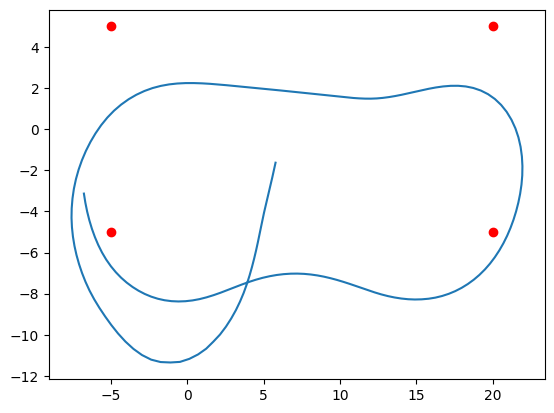

In [4]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(df.x, df.y)
ax.scatter(sensor_pos[..., 0], sensor_pos[..., 1], c="r")

In [5]:
# rr.init("traj_vis")
# # rr.connect_grpc()
# time = rr.TimeColumn("time", timestamp=ts)
# rr.log(
#     "sensors/location",
#     rr.Points3D(positions=sensor_pos, radii=[0.2] * 4),
#     static=True,
#     strict=True,
# )
# rr.log(
#     "traj/line",
#     rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
#     static=True,
#     strict=True,
# )

# rr.send_columns(
#     "traj/true",
#     indexes=[time],
#     columns=[
#         *rr.Points3D.columns(
#             positions=target_pos, radii=[0.5] * seq_len, colors=[(255, 0, 0)] * seq_len
#         )
#     ],
# )

# rr.send_columns(
#     "sensors/bearing",
#     indexes=[time],
#     columns=[
#         *rr.Arrows3D.columns(
#             vectors=bearing_meas.transpose(1, 0, 2).reshape(-1, 3) * 2,
#             origins=np.tile(sensor_pos, (1, seq_len, 1))
#             .transpose(1, 0, 2)
#             .reshape(-1, 3),
#         ).partition([4] * seq_len),
#     ],
# )
# rr.send_columns(
#     "sensors/range",
#     indexes=[time],
#     columns=[
#         *rr.Points3D.columns(
#             positions=np.tile(sensor_pos, (1, seq_len, 1))
#             .transpose(1, 0, 2)
#             .reshape(-1, 3),
#             radii=dist_meas.transpose().reshape(-1),
#             colors=[0x43ff644d] * 4*seq_len,
#         ).partition([4] * seq_len)
#     ],
# )

# # rr.send_columns(
# #     "traj/cloud",
# #     indexes=[rr.TimeColumn("time", timestamp=ts)],
# #     columns=[
# #         *rr.Points3D.columns(
# #             positions=cloud.transpose(1, 0, 2).reshape((-1, 3)),
# #             radii=radii.reshape((-1)),
# #         ).partition([n_points] * seq_len),
# #     ],
# # )

# rr.notebook_show()

In [92]:
from baja import pf, ekf, ukf, pff, GaussianState, ParticleState
import jax.numpy as jnp
import jax.random as jr
from functools import partial


def dynamics_fn(states):
    dt = 0.1  # because we resampled every 0.1s -> 10hz,
    A = np.block(
        [[np.eye(3), dt * np.eye(3)], [np.zeros((3, 3)), np.eye(3)]]
    )  # simple LTI process model
    return (A @ states.T).T


def dist_meas_fn(states, sensor_pos):
    """
    returns measurements (n_sensor, )
    [dist_0, dist_1, ...]
    """
    pos = states[:3]
    dist_meas = jnp.linalg.norm(pos - sensor_pos, axis=-1)
    return dist_meas


def bearing_meas_fn(states, sensor_pos):
    """
    returns measurements (n_sensor*2, )
    [az_0, el_0, az_1, el_1, ..., az_n, el_n]
    """
    pos = states[:3]
    b_vec = pos - sensor_pos

    dist = jnp.linalg.norm(b_vec, axis=-1)
    b_vec = b_vec / dist[:,None] # division is columns wise with shape (n,), so turn it to (1,n)

    elevs = jnp.asin(b_vec[..., 2])
    azims = jnp.atan2(b_vec[..., 1], b_vec[..., 0])
    return jnp.vstack([azims, elevs]).T.flatten()


def bearing_range_fn(states, sensor_pos):
    """
    returns measurements (n_sensor*3, )
    [dist_0, az_0, el_0, ...]
    """
    pos = states[:3]
    b_vec = pos - sensor_pos

    dist = jnp.linalg.norm(b_vec, axis=-1)
    b_vec = b_vec / dist[:, None]

    elevs = jnp.asin(b_vec[..., 2])
    azims = jnp.atan2(b_vec[..., 1], b_vec[..., 0])
    return jnp.vstack([dist, azims, elevs]).T.flatten()


key = jr.key(111)

sensor_type = "br"
if sensor_type == "r":
    sensor_pos = np.array(
        [
            [20, 5, 10],
            [20, -5, 10],
            [-5, 5, 10],
            [-5, -5, 10],
        ]
    )
    meas_dim = sensor_pos.shape[0]
    R = np.eye(meas_dim) * 0.1**2
    meas_fn = partial(dist_meas_fn, sensor_pos=sensor_pos)
elif sensor_type == "b":  # azimuth and elevation
    sensor_pos = np.array(
        [
            [20, 5, 10],
            [20, -5, 10],
            [-5, 5, 10],
            # [-5, -5, 10],
        ]
    )
    meas_dim = sensor_pos.shape[0] * 2
    angular_res = np.deg2rad(2)
    R = np.eye(meas_dim) * angular_res**2
    meas_fn = partial(bearing_meas_fn, sensor_pos=sensor_pos)
elif sensor_type == "br":
    sensor_pos = np.array(
        [
            [20, 5, 10],
            # [20, -5, 10],
            # [-5, 5, 10],
            # [-5, -5, 10],
        ]
    )
    meas_dim = sensor_pos.shape[0] * 3
    angular_res = np.deg2rad(2)
    R = np.diag([0.1**2, angular_res**2, angular_res**2])
    meas_fn = partial(bearing_range_fn, sensor_pos=sensor_pos)

Q = np.diag([1e-1, 1e-1, 1e-1, 0.5, 0.5, 0.5])

init_state = np.hstack([rng.normal(target_pos[0], size=(3,)), rng.uniform(-1, 1, (3,))])
state_ekf = GaussianState(mean=init_state, cov=Q)
filter_ekf = ekf.ExtendedKalmanFilter(
    f=dynamics_fn,
    h=meas_fn,
    Q=Q,
    R=R,
)

filter_ukf = ukf.UnscentedKalmanFilter(
    f=dynamics_fn,
    h=meas_fn,
    Q=Q,
    R=R,
)
state_ukf = state_ekf

n_particles = 10000
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)
state_bpf = ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter_bpf = pf.ParticleFilter(
    f=dynamics_fn,
    h=meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

n_particles = 100
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)
state_edh = ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter_edh = pff.EDHFilter(
    f=dynamics_fn,
    h=meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

params_iedh = pff.PFPFParam(
    internal_state=GaussianState(mean=init_state[0, ...], cov=Q)
)
state_iedh = pff.ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter_iedh = pff.IEDHFilter(
    f=dynamics_fn,
    h=meas_fn,
    internal_filter=filter_ukf,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

params_iledh = pff.PFPFParam(
    internal_state=GaussianState(mean=init_state, cov=np.tile(Q, (n_particles, 1, 1)))
)
state_iledh = state_iedh
filter_iledh = pff.ILEDHFilter(
    f=dynamics_fn,
    h=meas_fn,
    internal_filter=filter_ukf,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

In [94]:
rr.init("traj_vis")
bpf_hist = []
bpf_hist.append(state_bpf)

edh_hist = []
edh_hist.append(state_edh)

iedh_hist = []
iedh_hist.append(state_iedh)

iledh_hist = []
iledh_hist.append(state_iledh)

ekf_hist = []
ekf_hist.append(state_ekf)

ukf_hist = []
ukf_hist.append(state_ukf)

rr.log(
    "sensors/location",
    rr.Points3D(positions=sensor_pos, radii=[0.2] * sensor_pos.shape[0], labels=np.arange(3).astype(str)),
    static=True,
    strict=True,
)
rr.log(
    "traj/line",
    rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
    static=True,
    strict=True,
)

rr.log("traj/cloud_bpf", rr.Points3D(positions=state_bpf.particles[:, :3]))
rr.log("traj/cloud_edh", rr.Points3D(positions=state_edh.particles[:, :3]))
rr.log("traj/cloud_iedh", rr.Points3D(positions=state_iedh.particles[:, :3]))
rr.log("traj/cloud_iledh", rr.Points3D(positions=state_iledh.particles[:, :3]))
rr.log(
    "traj/ekf",
    rr.Points3D(
        positions=state_ekf.mean[:3],
        radii=[0.2],
        colors=[(0, 0, 255)],
    ),
)
rr.log(
    "traj/ukf",
    rr.Points3D(
        positions=state_ukf.mean[:3],
        radii=[0.2],
        colors=[(0, 255, 0)],
    ),
)

for i in range(seq_len):
    key, sub_key = jr.split(key)
    true_pos = target_pos[i, :]
    rr.log(
        "traj/true",
        rr.Points3D(positions=true_pos, radii=[0.1], colors=[(255, 0, 0)]),
    )
    # we probably need highly non-linear measurement model or non-gaussian distribution to demonstrate pfpf is better than EKF

    meas_noisy = meas_fn(true_pos) + jr.uniform(
        key=sub_key, shape=(meas_dim,), minval=-1, maxval=1
    ) * jnp.sqrt(jnp.diag(R))

    if sensor_type== 'br':
        m = meas_noisy.reshape(sensor_pos.shape[0], 3)
        dis = meas_noisy[...,0]
        azi = meas_noisy[...,1]
        ele = meas_noisy[...,2]
        vec = np.array([np.cos(ele)*np.cos(azi), np.cos(ele)*np.sin(azi), np.sin(ele)]) * dis
        rr.log("sensors/meas_noisy", rr.Arrows3D(vectors=vec.T, origins=sensor_pos, ))
    elif sensor_type == 'b':
        dis = 50 # a long enough line
        m = meas_noisy.reshape(sensor_pos.shape[0], 2)
        azi = m[...,0]
        ele = m[...,1]
        vec = np.array([np.cos(ele)*np.cos(azi), np.cos(ele)*np.sin(azi), np.sin(ele)]) * dis
        rr.log("sensors/meas_noisy", rr.Arrows3D(vectors=vec.T, origins=sensor_pos, ))
        
    elif sensor_type =='r':
        rr.log("sensors/meas_noisy", rr.Ellipsoids3D(radii=meas_noisy, centers=sensor_pos, ))
    
    state_bpf = filter_bpf.run_step(state_bpf, meas_noisy)
    bpf_hist.append(state_bpf)

    state_edh = filter_edh.run_step(state_edh, meas_noisy)
    edh_hist.append(state_edh)

    state_iedh, params_iedh = filter_iedh.run_step(
        state_iedh, meas_noisy, params=params_iedh
    )
    iedh_hist.append(state_iedh)

    state_iledh, params_iledh = filter_iledh.run_step(
        state_iledh, meas_noisy, params=params_iledh
    )
    iledh_hist.append(state_iledh)

    state_pred_ekf = filter_ekf.predict(state_ekf)
    state_ekf = filter_ekf.update(state_pred_ekf, meas_noisy)
    ekf_hist.append(state_ekf)

    state_pred_ukf = filter_ukf.predict(state_ukf)
    state_ukf = filter_ukf.update(state_pred_ukf, meas_noisy)
    ukf_hist.append(state_ukf)

    rr.log("traj/cloud_bpf", rr.Points3D(positions=state_bpf.particles[:, :3]))
    rr.log("traj/cloud_edh", rr.Points3D(positions=state_edh.particles[:, :3]))
    rr.log(
        "traj/cloud_iedh",
        rr.Points3D(
            positions=state_iedh.particles[:, :3], radii=state_iedh.weights * 0.5
        ),
    )

    rr.log(
        "traj/cloud_iledh",
        rr.Points3D(
            positions=state_iledh.particles[:, :3], radii=state_iedh.weights * 0.5
        ),
    )

    rr.log("traj/ekf", rr.Points3D(positions=state_ekf.mean[:3]))
    rr.log("traj/ukf", rr.Points3D(positions=state_ukf.mean[:3]))

    # state_pred = filter2.predict(state)
    # state = filter2.update(state, dist_noisy)
    # state_hist.append(state)
    # rr.log("ekf_est", rr.Points3D(positions=state.mean[:3]))
rr.notebook_show(width=960, height=720)

[2026-04-28T13:40:18Z WARN  re_sdk::log_sink] Dropping data in BufferedSink


HTML(value='<div id="981db0bb-e96d-454e-852b-a3ee0f468754"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

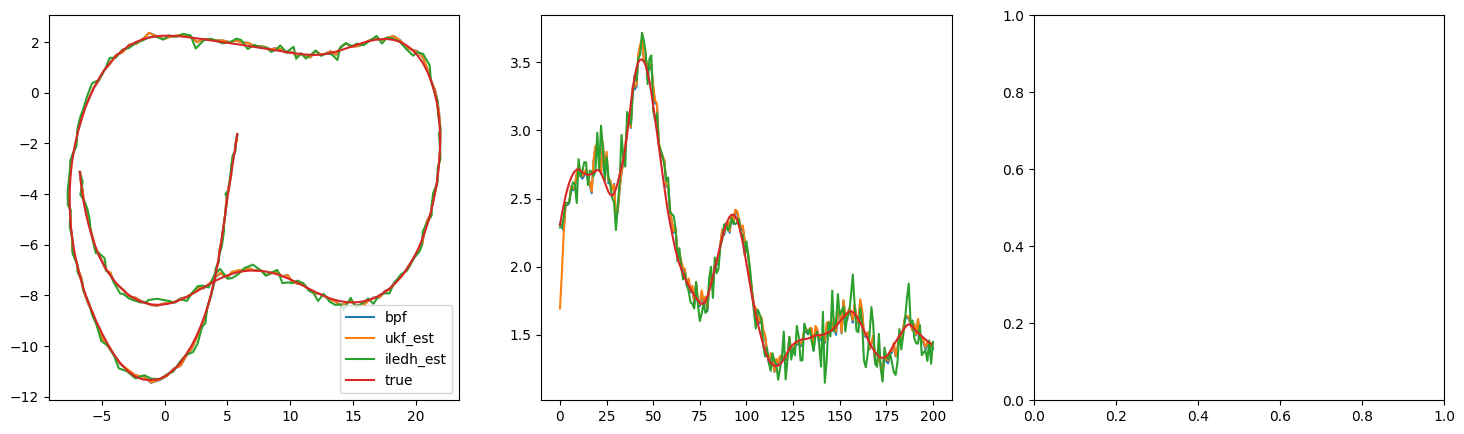

In [91]:
bpf_est = np.array([p.mean for p in bpf_hist])
edh_est = np.array([p.mean for p in edh_hist])
iedh_est = np.array([p.mean for p in iedh_hist])
ekf_est = np.array([s.mean for s in ekf_hist])
ukf_est = np.array([s.mean for s in ukf_hist])
iledh_est = np.array([p.mean for p in iledh_hist])

fig = plt.figure(0, figsize=(18, 5))
axs = fig.subplots(1, 3).flatten()

axs[0].plot(bpf_est[1:, 0], bpf_est[1:, 1], label="bpf")
# axs[0].plot(edh_est[1:, 0], edh_est[1:, 1], label="edh")
# axs[0].plot( iedh_est[1:, 0], iedh_est[1:, 1], label="iedh")
# axs[0].plot( ekf_est[1:, 0], ekf_est[1:, 1], label="ekf_est")
axs[0].plot(ukf_est[1:, 0], ukf_est[1:, 1], label="ukf_est")
axs[0].plot(iledh_est[1:, 0], iledh_est[1:, 1], label="iledh_est")

axs[0].plot(target_pos[..., 0], target_pos[..., 1], label="true")
axs[0].legend()

axs[1].plot(bpf_est[:, 2])
# axs[1].plot(edh_est[:, 2])
# axs[1].plot(iedh_est[:, 2])
# axs[1].plot(ekf_est[:, 2])
axs[1].plot(ukf_est[:, 2])
axs[1].plot(iledh_est[:, 2])
axs[1].plot(target_pos[..., 2])

# axs[2].plot(means1[1:, 3:])
# axs[2].plot(means2[1:, 3:])
# axs[2].plot(means3[1:, 3:])
# axs[2].plot(means4[1:, 3:])
# axs[2].plot(means5[1:, 3:])

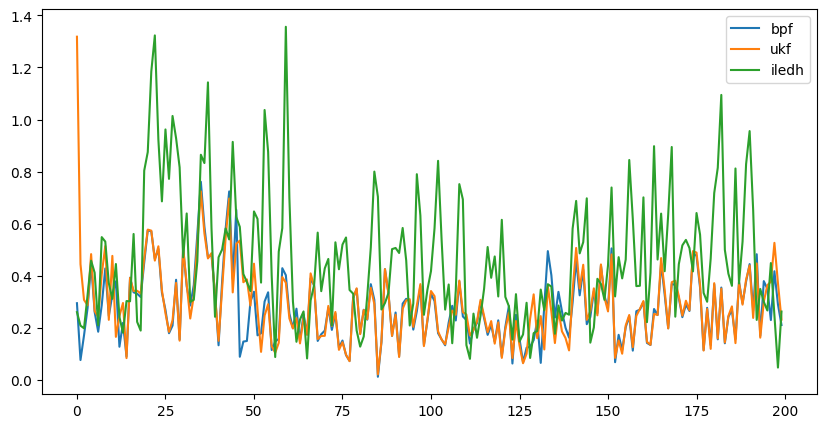

In [81]:
fig = plt.figure(1, figsize=(10, 5))
ax = fig.add_subplot()

ax.plot(jnp.linalg.norm(bpf_est[1:, :3] - target_pos, axis=-1), label="bpf")
# ax.plot(jnp.linalg.norm(edh_est[:-1, :3] - target_pos, axis=-1), label="edh")
# ax.plot(jnp.linalg.norm(ekf_est[:-1, :3] - target_pos, axis=-1), label="ekf")
ax.plot(jnp.linalg.norm(ukf_est[1:, :3] - target_pos, axis=-1), label="ukf")
# ax.plot(jnp.linalg.norm(iedh_est[:-1, :3] - target_pos, axis=-1), label="iedh")
ax.plot(jnp.linalg.norm(iledh_est[1:, :3] - target_pos, axis=-1), label="iledh")

ax.legend()